# Plot Malina Oceanographic Campaign CTD profiles

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gsw
import os
from pyproj import Proj, Transformer
import boto3
import s3fs
import pyresample as pr
from matplotlib.lines import Line2D

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:45487")
client

<Client: 'tcp://127.0.0.1:45487' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# load CSV
df = pd.read_csv('~/efs-mount-point/mzahn/sassie/MALINA_ocean_campaign/ctd.csv', sep=",")
df['start_date_time_utc'] = pd.to_datetime(df['start_date_time_utc'])

In [4]:
# Rename columns for convenience
df = df.rename(columns={
    'start_date_time_utc': 'time',
    'initial_latitude_deg': 'lat',
    'initial_longitude_deg': 'lon',
    'max_depth_m': 'max_depth',
    'pres': 'pressure',
    'temp': 'temperature',
    'sal': 'salinity',
    'sigthe': 'potential_dens'
})

# Build xarray Dataset
# We want dims = (time, pressure)
# But pressure varies per cast, so we group by each timestamp

ds_list = []

for t, g in df.groupby('time'):
    g = g.sort_values('pressure')  # ensure ordered

    # Create a dataset for this cast
    dsi = xr.Dataset(
        {
            'temperature': ('pressure', g['temperature'].values),
            'salinity': ('pressure', g['salinity'].values),
            'potential_dens': ('pressure', g['potential_dens'].values),
        },
        coords={
            'pressure': g['pressure'].values,
            'time': np.datetime64(t),
            'cast_number': g['cast_number'].iloc[0],
            'lat': g['lat'].iloc[0],
            'lon': g['lon'].iloc[0],
            'max_depth': g['max_depth'].iloc[0],
        }
    )

    ds_list.append(dsi)

# combine all casts along *time* dimension
ds = xr.concat(ds_list, dim='time')
ctd_ds = ds.sortby('time')

ctd_ds

/tmp/ipykernel_64281/42759460.py:31: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  'time': np.datetime64(t),


<xarray.Dataset> Size: 7MB
Dimensions:         (time: 165, pressure: 1804)
Coordinates:
  * pressure        (pressure) int64 14kB 3 4 5 6 7 ... 1802 1803 1804 1805 1806
  * time            (time) datetime64[us] 1kB 2009-07-31T21:08:31 ... 2009-08...
    cast_number     (time) int64 1kB 25 26 27 28 29 30 ... 187 188 189 190 191
    lat             (time) float64 1kB 70.18 70.18 70.18 ... 71.74 71.72 71.71
    lon             (time) float64 1kB -133.6 -133.6 -133.6 ... -130.8 -130.8
    max_depth       (time) float64 1kB 46.05 35.88 35.73 ... 514.4 297.2 300.0
Data variables:
    temperature     (time, pressure) float64 2MB 5.022 5.172 4.987 ... nan nan
    salinity        (time, pressure) float64 2MB nan 27.23 27.33 ... nan nan nan
    potential_dens  (time, pressure) float64 2MB nan 21.5 21.6 ... nan nan nan

In [5]:
# open bathymetry
bathy_ds = xr.open_dataset('~/efs-mount-point/mzahn/bathy/gebco_2024_n90.0_s30.0_w-179.0_e-110.0.nc')

# select the coordinate range and every 5th point
bathy_beaufort = bathy_ds.elevation.sel(lat=slice(68,80),lon=slice(-170,-120)).isel(lat=slice(None, None, 10), lon=slice(None, None, 10)).load()

## Compute MLD

In [6]:
def compute_mld(ctd_ds, rho_thresh=0.1):

    # Broadcast latitude + longitude to match (time, z)
    lat2d = ctd_ds.lat.broadcast_like(ctd_ds.salinity)
    lon2d = ctd_ds.lon.broadcast_like(ctd_ds.salinity)

    mld_list = []

    # Loop profiles
    for t in ctd_ds.time.values:
        # print(t)
        rho_profile = ctd_ds.potential_dens.sel(time=t)
        depth_profile = ctd_ds.pressure  # same for all times

        # reference density at **uppermost valid measurement**
        valid_idx = np.where(~np.isnan(rho_profile.values))[0]
        if len(valid_idx) == 0:
            mld_list.append(np.nan)
            continue

        rho0 = rho_profile.isel(pressure=valid_idx[0]).values

        # density anomaly relative to surface
        drho = rho_profile - rho0

        # first z where drho >= threshold
        idx = np.argmax(drho.values >= rho_thresh)

        if drho[idx] >= rho_thresh:
            mld = depth_profile.isel(pressure=idx).item()
        else:
            mld = np.nan  # no mixed layer depth found

        mld_list.append(mld)

    # Return as DataArray
    return xr.DataArray(
        mld_list,
        coords={'time': ctd_ds.time},
        dims=['time'],
        name='MLD',
        attrs={'units': 'm', 'long_name': 'Mixed Layer Depth (0.1 kg/m^3 threshold)'}
    )

In [7]:
mld_da = compute_mld(ctd_ds, rho_thresh=0.1)

### Open satellite SIC

In [8]:
# Set data directory and load all matching NetCDF files
sic_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr"
sic_path = sorted(glob.glob(os.path.join(sic_dir, f"*20091020*.nc")))

In [9]:
# open dataset
ice_bridge_ds = xr.open_dataset(sic_path[0])
ice_bridge_da = ice_bridge_ds.cdr_seaice_conc.squeeze()

In [10]:
# Define NSIDC stereographic projection
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# Lat/lon
x = ice_bridge_da['x'].values
y = ice_bridge_da['y'].values
X, Y = np.meshgrid(x, y)
lon, lat = transformer.transform(X, Y)

### Open model data

In [11]:
def get_aws_credentials(profile_name='sassie'):
    session = boto3.Session(profile_name=profile_name)
    credentials = session.get_credentials()
    return credentials

In [12]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, aws_credentials):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(anon=False, key=aws_credentials.access_key, secret=aws_credentials.secret_key)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [13]:
# get creds
aws_credentials = get_aws_credentials(profile_name='sassie_read')

In [14]:
# open SIarea zarr store - [fraction of sea ice, 0 to 1]
# sic_model_ds = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', aws_credentials)
salt_model_ds = open_zarr_store('s3://podaac-dev-sassie/ECCO_model/N1/V1R1/HH/ZARR/SALT_AVG_DAILY.ZARR/', aws_credentials)

In [15]:
# select beaufort sea box and reduce domain size
# sic_beaufort_da = (sic_model_ds.SIarea*100).isel(i=slice(510,850),j=slice(0,500))
salt_beaufort_da = salt_model_ds.SALT.isel(k=slice(2,7),i=slice(510,850),j=slice(0,500))

In [16]:
# calculate avg august surface salinity

# select all August days
salt_aug = salt_beaufort_da.sel(time=salt_beaufort_da.time.dt.month == 8)

# Take the multi-year mean (average over all August days)
salt_aug_mean = salt_aug.mean(dim=['time','k'])

In [32]:
# --- MODEL GRID (2-D) ---
model_lon = salt_aug_mean['XC'].values
model_lat = salt_aug_mean['YC'].values
model_data_flat = salt_aug_mean.values.ravel()
model_swath = pr.geometry.SwathDefinition(lons=model_lon.ravel(), lats=model_lat.ravel())

# --- CTD OBS LOCATIONS (1-D) ---
obs_lon = ctd_ds['lon'].values
obs_lat = ctd_ds['lat'].values
obs_swath = pr.geometry.SwathDefinition(lons=obs_lon, lats=obs_lat)

# --- NEAREST NEIGHBOR SEARCH ---
idx, dist, idx_valid, dist_valid = pr.kd_tree.get_neighbour_info(
    source_geo_def=model_swath,
    target_geo_def=obs_swath,
    radius_of_influence=5e4,  # 50 km
    neighbours=1
)

# --- EXTRACT MODEL VALUES AT CTD LOCS ---
# out = np.full_like(obs_lon, np.nan, dtype=float)
out = model_data_flat[idx_valid]

model_at_ctd = xr.DataArray(out, dims="time", coords={"time": ctd_ds.time}, name="model_salinity_at_ctd")

In [33]:
# pull out lat/lon for each profile
model_lon_flat = model_lon.ravel()
model_lat_flat = model_lat.ravel()

model_ctd_lon = model_lon_flat[idx_valid]
model_ctd_lat = model_lat_flat[idx_valid]

In [48]:
# # pull out whole profile
# salt_full = salt_model_ds.SALT.isel(i=slice(510,850),j=slice(0,500))

# # select all August days
# salt_full_aug = salt_full.sel(time=salt_full.time.dt.month == 8)

# # Take the multi-year mean (average over all August days)
salt_full_aug_mean = salt_full_aug.mean(dim=['time'])

# also take standard deviation
salt_full_aug_std = salt_full_aug.std(dim=['time'])

In [35]:
# RMS error
rms = np.sqrt(np.nanmean((model_at_ctd - salt)**2))
print("RMS error:", rms)

RMS error: 1.66469132186953


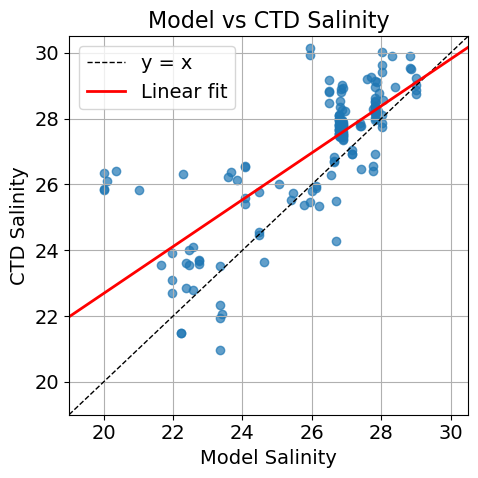

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten and remove NaNs
x = np.ravel(model_at_ctd)
y = np.ravel(salt)
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# Scatter plot
plt.figure(figsize=(5,5))
plt.scatter(x, y, marker='o', alpha=0.7)

# 1:1 line
xymin = 19
xymax = 30.5
plt.plot([xymin, xymax], [xymin, xymax], 'k--', linewidth=1, label='y = x')

# Linear fit
slope, intercept = np.polyfit(x, y, 1)
fit_line = slope * np.array([xymin, xymax]) + intercept
plt.plot([xymin, xymax], fit_line, 'r-', linewidth=2, label=f'Linear fit')

# Labels and title
plt.xlabel("Model Salinity", fontsize=14)
plt.ylabel("CTD Salinity", fontsize=14)
plt.title("Model vs CTD Salinity", fontsize=16)

plt.xlim(xymin, xymax)
plt.ylim(xymin, xymax)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/ctd_model_comparison_scatter_plot.png',
            dpi=300, bbox_inches='tight')

plt.show()

In [42]:
corr = np.corrcoef(x, y)[0, 1]
print("Correlation coefficient:", corr)

Correlation coefficient: 0.7698611353323936


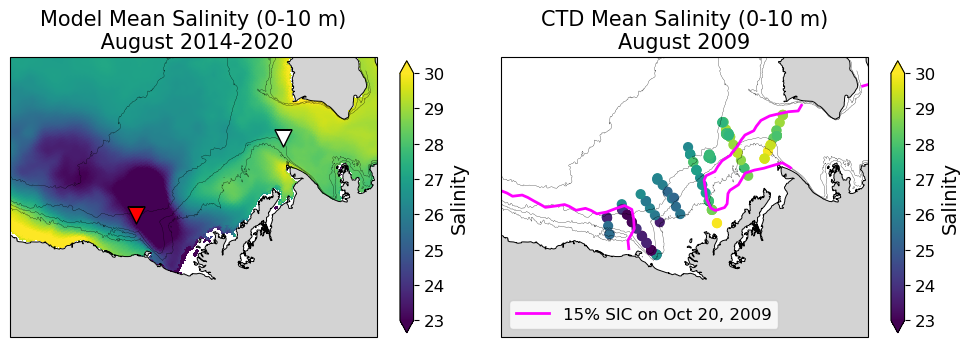

In [44]:
plt.rcParams['font.size'] = 12

# --- extract profile-level coords/vars ---
lats = ctd_ds['lat'].values
lons = ctd_ds['lon'].values
temp = ctd_ds['temperature'].sel(pressure=slice(0,10)).mean('pressure').values
salt = ctd_ds['salinity'].sel(pressure=slice(0,10)).mean('pressure').values

# --- projection and figure ---
proj = ccrs.NorthPolarStereo(central_longitude=-150)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': proj})

for ax in axes:
    ax.set_extent([-148, -125, 68, 73], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    # ax.gridlines(draw_labels=False, linewidth=0.3, color='gray')

    # add isobaths
    bathy_beaufort.plot.contour(ax=ax,levels=[-50,-100,-1000,-3000],colors='k',linewidths=0.2,linestyles='solid',transform=ccrs.PlateCarree())

# --- left: colored by max depth ---
# Coordinates from HH_land_beaufort
lon = salt_aug_mean['XC'].values
lat = salt_aug_mean['YC'].values

# pcolormesh in PlateCarree for correct lat/lon placement
pcm = axes[0].pcolormesh(
    lon, lat, salt_aug_mean.values,
    # lon, lat, salt_aug.isel(k=0).sel(time='2020-08-15').squeeze().values,
    transform=ccrs.PlateCarree(),
    cmap='viridis', vmin=23, vmax=30
)
axes[0].set_title('Model Mean Salinity (0-10 m)\n August 2014-2020', fontsize=15)
cb1 = fig.colorbar(pcm, ax=axes[0], orientation='vertical', shrink=0.75,extend='both')
cb1.set_label("Salinity", fontsize=14)

# add location of corresponding profiles
# axes[0].scatter(model_ctd_lon, model_ctd_lat, marker='o', facecolors='none', edgecolor='white', s=60, transform=ccrs.PlateCarree())

# --- right: colored by DOY ---
sc2 = axes[1].scatter(
    lons, lats,
    c=salt,vmin=23,vmax=30,
    cmap='viridis',
    s=40,
    transform=ccrs.PlateCarree()
)
axes[1].set_title('CTD Mean Salinity (0-10 m)\nAugust 2009', fontsize=15)

cb2 = fig.colorbar(sc2, ax=axes[1], orientation='vertical', shrink=0.75,extend='both')
cb2.set_label("Salinity", fontsize=14)

# add SIC contour
# Define NSIDC stereographic projection
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# Lat/lon
x = ice_bridge_da['x'].values
y = ice_bridge_da['y'].values
X, Y = np.meshgrid(x, y)
lon, lat = transformer.transform(X, Y)
axes[1].contour(lon, lat, ice_bridge_da.values, levels=[0.15], colors='magenta',linewidths=2, transform=ccrs.PlateCarree())

# create custom legend entry for contour
contour_line = Line2D([0], [0], color='magenta', lw=2, label='15% SIC on Oct 20, 2009')
axes[1].legend(handles=[contour_line], loc='lower left')

axes[0].scatter(model_ctd_lon[70], model_ctd_lat[70], marker='v',color='r',edgecolor='k',s=150,transform=ccrs.PlateCarree(),zorder=3)
axes[0].scatter(model_ctd_lon[36], model_ctd_lat[36], marker='v',color='white',edgecolor='k',s=150,transform=ccrs.PlateCarree(),zorder=3)

fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/ctd_model_comparison_maps.png',
            dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [45]:
plume_i=70
adj_i = 36

In [46]:
# isolate profiles in model that correspond to where MALINA profiles were
model_plume_prof = salt_full_aug_mean.where((salt_full_aug_mean.XC==model_ctd_lon[plume_i]).compute(),drop=True).squeeze().load()
model_adj_prof = salt_full_aug_mean.where((salt_full_aug_mean.XC==model_ctd_lon[adj_i]).compute(),drop=True).squeeze().load()

In [50]:
# also pull out standard deviation
model_plume_prof_std = salt_full_aug_std.where((salt_full_aug_std.XC==model_ctd_lon[plume_i]).compute(),drop=True).squeeze().load()
model_adj_prof_std = salt_full_aug_std.where((salt_full_aug_std.XC==model_ctd_lon[adj_i]).compute(),drop=True).squeeze().load()

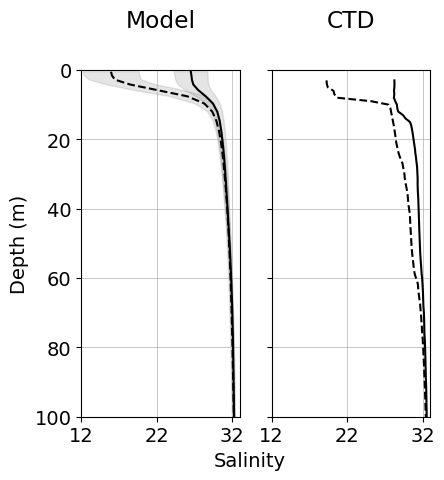

In [60]:
plt.rcParams['font.size'] = 14
fig, (ax1,ax2) = plt.subplots(1,2, figsize=[4.5,4.5], sharey=True, sharex=True)

## --- MODEL PROFILES ---
depth = model_plume_prof.Z * -1   # depth array used by both profiles

# Plume profile (dashed)
ax1.plot(model_plume_prof, depth, color='k', linestyle='--')
# Plume ± std shading
ax1.fill_betweenx(depth,
                  model_plume_prof - model_plume_prof_std,
                  model_plume_prof + model_plume_prof_std,
                  color='gray', alpha=0.2)

# Adjacent profile (solid)
ax1.plot(model_adj_prof, depth, color='k')
# Adjacent ± std shading
ax1.fill_betweenx(depth,
                  model_adj_prof - model_adj_prof_std,
                  model_adj_prof + model_adj_prof_std,
                  color='gray', alpha=0.2)


## --- CTD PROFILES ---
ctd_ds.salinity.isel(time=plume_i).plot(ax=ax2, y='pressure', color='k', linestyle='--')
ctd_ds.salinity.isel(time=adj_i).plot(ax=ax2,   y='pressure', color='k')

## --- AXES, LABELS, GRID ---
ax1.set_xlim(12, 33)
ax1.set_xticks([12, 22, 32])
ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel('Depth (m)')
ax2.set_ylabel('')

ax1.set_title("Model", y=1.1)
ax2.set_title("CTD", y=1.1)

ax1.grid(linewidth=0.5)
ax2.grid(linewidth=0.5)

ax1.set_ylim(100, 0)
fig.text(0.5, 0, r'Salinity', ha='center', fontsize=14)

fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/ctd_model_comparison_profs.png',
            dpi=300, bbox_inches='tight')